# CS515 HW4 — Sequence Modeling
**Sabancı University | Deep Learning**

This notebook runs all experiments for HW4:
- **Part 1 (a)**: Download AAPL / MSFT / GOOGL data via `yfinance`
- **Part 1 (b)**: StockLSTM & StockGRU — exact d-day return forecasting
- **Part 1 (c)**: Rolling-average return forecasting (l=3)
- **Part 1 (d)**: Bi-directional LSTM/GRU — turning-point (buy/pass) detection
- **Part 2 (bonus)**: Transformer-based interactive AWGN communication system

> Make sure **Runtime → Change runtime type → GPU (T4)** is selected.

## 0. Setup — Clone Repo & Install Dependencies

In [1]:
import os

# Temizle
!rm -rf CS515-HW4

# Clone et (repo adını kontrol et)
!git clone https://github.com/berkay888/CS515-HW4.git

# Dizine gir
%cd CS515-HW4

!pip install -r requirements.txt -q

os.makedirs('results/figures', exist_ok=True)
os.makedirs('results/checkpoints', exist_ok=True)

Cloning into 'CS515-HW4'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 23 (delta 4), reused 16 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 23.75 KiB | 23.75 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/CS515-HW4


In [2]:
import sys, os
sys.path.insert(0, '.')

import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


## Part (a) — Dataset
Download AAPL, MSFT, GOOGL (2020-01-01 – 2025-12-31) using `yfinance`.

- **Train**: Jan 2020 – Jul 2024
- **Val**: Aug 2024 – Dec 2024
- **Test**: Jan 2025 – Dec 2025

In [3]:
from parameters import DataConfig, ReturnConfig, RollingConfig, TurningPointConfig, CommConfig
from utils.dataset import download_data, split_df

data_cfg = DataConfig()
print('Downloading data for:', data_cfg.tickers)
all_data = download_data(data_cfg)

# Quick summary
for ticker, df in all_data.items():
    tr, va, te = split_df(df, data_cfg)
    print(f'{ticker}: train={len(tr)}, val={len(va)}, test={len(te)}')

  AAPL: 1507 trading days downloaded.
  MSFT: 1507 trading days downloaded.
  GOOGL: 1507 trading days downloaded.
AAPL: train=1152, val=106, test=249
MSFT: train=1152, val=106, test=249
GOOGL: train=1152, val=106, test=249


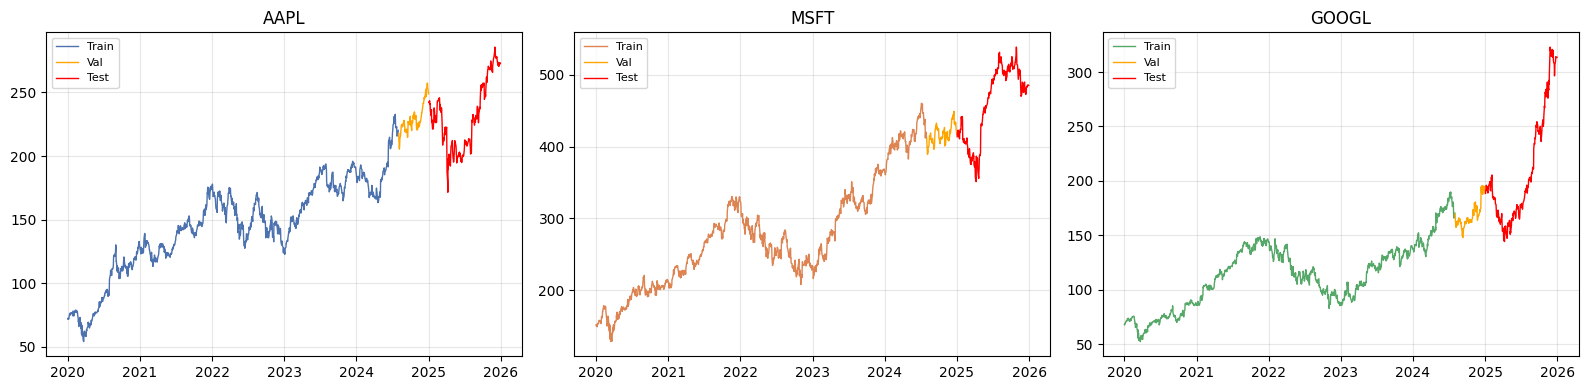

In [4]:
# Visualise closing prices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ['#4C72B0', '#DD8452', '#55A868']
for ax, (ticker, df), c in zip(axes, all_data.items(), colors):
    tr, va, te = split_df(df, data_cfg)
    ax.plot(tr.index, tr['Close'], color=c, label='Train', lw=1)
    ax.plot(va.index, va['Close'], color='orange', label='Val', lw=1)
    ax.plot(te.index, te['Close'], color='red', label='Test', lw=1)
    ax.set_title(ticker); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/stock_prices.png', dpi=150, bbox_inches='tight')
plt.show()

## Part (b) — StockLSTM & StockGRU: Exact d-day Return Forecasting

$$r_i^{t+d} = \frac{p_i^{t+d} - p_i^t}{p_i^t}, \quad d \in \{1,2,3,4,5\}$$

In [5]:
from models.stock_lstm import StockLSTM
from models.stock_gru  import StockGRU
from utils.dataset import build_return_loaders
from utils.metrics import per_horizon_mse, mae, directional_accuracy
from utils.visualization import plot_loss_curves, plot_per_horizon_mse
from train import train_regression

ret_cfg = ReturnConfig()
n_feat  = len(data_cfg.features)
n_hor   = len(data_cfg.horizons)

train_loader, val_loader, test_loader, _ = build_return_loaders(
    all_data, data_cfg, ret_cfg.batch_size
)
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 52 | Val: 4 | Test: 11


In [6]:
# ── Train StockLSTM ──
lstm_ret = StockLSTM(n_feat, ret_cfg.hidden_size, ret_cfg.num_layers, n_hor, ret_cfg.dropout)
print(f'StockLSTM params: {sum(p.numel() for p in lstm_ret.parameters()):,}')

tr_l, val_l = train_regression(
    lstm_ret, train_loader, val_loader,
    epochs=ret_cfg.epochs, lr=ret_cfg.lr,
    weight_decay=ret_cfg.weight_decay,
    patience=ret_cfg.patience,
    device=device, ckpt_name='return_lstm'
)
plot_loss_curves(tr_l, val_l, 'Part (b) LSTM — MSE Loss', 'return_lstm_loss.png')

StockLSTM params: 203,409
  Epoch   1/50 | train MSE 0.001250 | val MSE 0.000641
  Epoch  10/50 | train MSE 0.001035 | val MSE 0.000660
  Early stopping at epoch 14.
  Saved → results/figures/return_lstm_loss.png


In [7]:
# ── Train StockGRU ──
gru_ret = StockGRU(n_feat, ret_cfg.hidden_size, ret_cfg.num_layers, n_hor, ret_cfg.dropout)
print(f'StockGRU params: {sum(p.numel() for p in gru_ret.parameters()):,}')

tr_g, val_g = train_regression(
    gru_ret, train_loader, val_loader,
    epochs=ret_cfg.epochs, lr=ret_cfg.lr,
    weight_decay=ret_cfg.weight_decay,
    patience=ret_cfg.patience,
    device=device, ckpt_name='return_gru'
)
plot_loss_curves(tr_g, val_g, 'Part (b) GRU — MSE Loss', 'return_gru_loss.png')

StockGRU params: 152,721
  Epoch   1/50 | train MSE 0.001804 | val MSE 0.000697
  Epoch  10/50 | train MSE 0.001042 | val MSE 0.000669
  Early stopping at epoch 14.
  Saved → results/figures/return_gru_loss.png


In [8]:
# ── Evaluate on test set ──
def collect(model, loader):
    model.eval(); ps, ts = [], []
    with torch.no_grad():
        for X, y in loader:
            ps.append(model(X.to(device)).cpu()); ts.append(y)
    return torch.cat(ps), torch.cat(ts)

pred_l, tgt = collect(lstm_ret, test_loader)
pred_g, _   = collect(gru_ret,  test_loader)

mse_lstm = per_horizon_mse(pred_l, tgt)
mse_gru  = per_horizon_mse(pred_g, tgt)

print('\nPart (b) Test Results:')
print(f'{"d":>4} | {"LSTM MSE":>12} | {"GRU MSE":>12}')
print('-' * 35)
for d, ml, mg in zip(data_cfg.horizons, mse_lstm, mse_gru):
    print(f'd={d}  | {ml:12.6f} | {mg:12.6f}')
print(f'Avg  | {mse_lstm.mean():12.6f} | {mse_gru.mean():12.6f}')
print(f'\nLSTM Dir.Acc: {directional_accuracy(pred_l, tgt):.4f} | GRU Dir.Acc: {directional_accuracy(pred_g, tgt):.4f}')

plot_per_horizon_mse(mse_lstm, mse_gru, 'Part (b) Per-Horizon MSE', 'return_horizon_mse.png')


Part (b) Test Results:
   d |     LSTM MSE |      GRU MSE
-----------------------------------
d=1  |     0.000366 |     0.000392
d=2  |     0.000714 |     0.000708
d=3  |     0.001148 |     0.001145
d=4  |     0.001504 |     0.001505
d=5  |     0.001843 |     0.001807
Avg  |     0.001115 |     0.001112

LSTM Dir.Acc: 0.5521 | GRU Dir.Acc: 0.5435
  Saved → results/figures/return_horizon_mse.png


## Part (c) — Rolling Average Return Forecasting

$$\hat{r}_i^{t+d} = \frac{\sum_{j=0}^{l-1} w_j \, p_i^{t+d-j} - p_i^t}{p_i^t}, \quad l=3$$

In [9]:
from utils.dataset import build_rolling_loaders
from utils.visualization import plot_return_vs_rolling

roll_cfg = RollingConfig()
tr_roll, val_roll, te_roll = build_rolling_loaders(all_data, data_cfg, roll_cfg, roll_cfg.batch_size)

lstm_rol = StockLSTM(n_feat, ret_cfg.hidden_size, ret_cfg.num_layers, n_hor, ret_cfg.dropout)
tr_lr, val_lr = train_regression(
    lstm_rol, tr_roll, val_roll,
    epochs=roll_cfg.epochs, lr=roll_cfg.lr,
    weight_decay=roll_cfg.weight_decay, patience=roll_cfg.patience,
    device=device, ckpt_name='rolling_lstm'
)
plot_loss_curves(tr_lr, val_lr, 'Part (c) LSTM Rolling — MSE Loss', 'rolling_lstm_loss.png')

  Epoch   1/50 | train MSE 0.001333 | val MSE 0.000686
  Epoch  10/50 | train MSE 0.001087 | val MSE 0.000692
  Early stopping at epoch 13.
  Saved → results/figures/rolling_lstm_loss.png


In [10]:
gru_rol = StockGRU(n_feat, ret_cfg.hidden_size, ret_cfg.num_layers, n_hor, ret_cfg.dropout)
tr_gr, val_gr = train_regression(
    gru_rol, tr_roll, val_roll,
    epochs=roll_cfg.epochs, lr=roll_cfg.lr,
    weight_decay=roll_cfg.weight_decay, patience=roll_cfg.patience,
    device=device, ckpt_name='rolling_gru'
)
plot_loss_curves(tr_gr, val_gr, 'Part (c) GRU Rolling — MSE Loss', 'rolling_gru_loss.png')

  Epoch   1/50 | train MSE 0.001578 | val MSE 0.001108
  Epoch  10/50 | train MSE 0.001100 | val MSE 0.000685
  Early stopping at epoch 17.
  Saved → results/figures/rolling_gru_loss.png


In [11]:
pred_lr, tgt_r = collect(lstm_rol, te_roll)
pred_gr, _     = collect(gru_rol,  te_roll)
mse_rol_l = per_horizon_mse(pred_lr, tgt_r)
mse_rol_g = per_horizon_mse(pred_gr, tgt_r)

print('\nPart (c) vs Part (b) MSE Comparison (LSTM):')
print(f'{"d":>4} | {"Exact":>10} | {"Rolling":>10} | {"Diff":>10}')
print('-' * 42)
for d, me, mr in zip(data_cfg.horizons, mse_lstm, mse_rol_l):
    print(f'd={d}  | {me:10.6f} | {mr:10.6f} | {mr - me:+10.6f}')

plot_return_vs_rolling(mse_lstm, mse_rol_l, mse_gru, mse_rol_g)


Part (c) vs Part (b) MSE Comparison (LSTM):
   d |      Exact |    Rolling |       Diff
------------------------------------------
d=1  |   0.000366 |   0.000494 |  +0.000128
d=2  |   0.000714 |   0.000890 |  +0.000176
d=3  |   0.001148 |   0.001258 |  +0.000110
d=4  |   0.001504 |   0.001581 |  +0.000077
d=5  |   0.001843 |   0.001894 |  +0.000051
  Saved → results/figures/return_vs_rolling_comparison.png


## Part (d) — Turning-Point Detection with Bi-directional LSTM/GRU

Buy signal if $\exists d: \frac{p_i^{\max,t+d} - p_i^t}{p_i^t} > \gamma$, where $p_i^{\max,t+d}$ = High price on day $t+d$.

In [22]:
from utils.dataset import build_tp_loaders
from utils.metrics import binary_metrics
from utils.visualization import plot_confusion_matrix
from train import train_classification
from sklearn.metrics import confusion_matrix

tp_cfg = TurningPointConfig()
tp_cfg.gamma = 0.05
tr_tp, val_tp, te_tp, pos_w = build_tp_loaders(all_data, data_cfg, tp_cfg, tp_cfg.batch_size)

# Count class distribution
all_labels = torch.cat([y for _, y in tr_tp])
n_buy  = int(all_labels.sum().item())
n_pass = len(all_labels) - n_buy
print(f'Train — Buy: {n_buy} ({100*n_buy/len(all_labels):.1f}%) | Pass: {n_pass}')
print(f'Positive-class weight: {pos_w.item():.3f}')

Train — Buy: 701 (21.1%) | Pass: 2627
Positive-class weight: 3.715


In [23]:
# ── Bi-directional LSTM ──
bi_lstm = StockLSTM(n_feat, tp_cfg.hidden_size, tp_cfg.num_layers,
                     output_size=1, dropout=tp_cfg.dropout, bidirectional=True)
print(f'Bi-LSTM params: {sum(p.numel() for p in bi_lstm.parameters()):,}')

tr_bl, val_bl = train_classification(
    bi_lstm, tr_tp, val_tp,
    epochs=tp_cfg.epochs, lr=tp_cfg.lr,
    weight_decay=tp_cfg.weight_decay, patience=tp_cfg.patience,
    device=device, ckpt_name='tp_bilstm', pos_weight=pos_w
)
plot_loss_curves(tr_bl, val_bl, 'Part (d) Bi-LSTM — BCE Loss', 'tp_bilstm_loss.png')

Bi-LSTM params: 536,845
  Epoch   1/50 | train BCE 1.0207 | val BCE 1.0122
  Epoch  10/50 | train BCE 1.0071 | val BCE 0.8928
  Early stopping at epoch 12.
  Saved → results/figures/tp_bilstm_loss.png


In [24]:
# ── Bi-directional GRU ──
bi_gru = StockGRU(n_feat, tp_cfg.hidden_size, tp_cfg.num_layers,
                   output_size=1, dropout=tp_cfg.dropout, bidirectional=True)
tr_bg, val_bg = train_classification(
    bi_gru, tr_tp, val_tp,
    epochs=tp_cfg.epochs, lr=tp_cfg.lr,
    weight_decay=tp_cfg.weight_decay, patience=tp_cfg.patience,
    device=device, ckpt_name='tp_bigru', pos_weight=pos_w
)
plot_loss_curves(tr_bg, val_bg, 'Part (d) Bi-GRU — BCE Loss', 'tp_bigru_loss.png')

  Epoch   1/50 | train BCE 1.0113 | val BCE 0.8692
  Epoch  10/50 | train BCE 1.0073 | val BCE 0.8523
  Early stopping at epoch 13.
  Saved → results/figures/tp_bigru_loss.png


In [27]:
for name, model in [('Bi-LSTM', bi_lstm), ('Bi-GRU', bi_gru)]:
    pred, lab = collect(model, te_tp)
    pred = pred.squeeze(-1)
    m = binary_metrics(pred, lab, threshold=0.3)  # threshold=0.3
    print(f'\n{name}:')
    for k, v in m.items(): print(f'  {k:12s}: {v:.4f}')
    probs = torch.sigmoid(pred).numpy()
    preds_bin = (probs >= 0.3).astype(int)
    cm = confusion_matrix(lab.numpy().astype(int), preds_bin)
    print(f'  Confusion Matrix:\n{cm}')
    plot_confusion_matrix(cm, f'Turning Point — {name}', f'cm_{name.replace("-","").lower()}.png')


Bi-LSTM:
  accuracy    : 0.8274
  precision   : 0.8214
  recall      : 0.1716
  f1          : 0.2840
  auc         : 0.5820
  Confusion Matrix:
[[533   5]
 [111  23]]
  Saved → results/figures/cm_bilstm.png

Bi-GRU:
  accuracy    : 0.6250
  precision   : 0.2659
  recall      : 0.5000
  f1          : 0.3472
  auc         : 0.5860
  Confusion Matrix:
[[353 185]
 [ 67  67]]
  Saved → results/figures/cm_bigru.png


## Part 2 (Bonus) — Interactive AWGN Communication System

TX (Transformer) → AWGN channel → RX (Transformer), with T=4 rounds of noiseless feedback.

In [16]:
from models.comm_system import InteractiveCommSystem
from utils.metrics import symbol_error_rate, message_error_rate
from utils.visualization import plot_comm_curves, plot_snr_vs_error
from train import train_comm

comm_cfg = CommConfig()
comm_model = InteractiveCommSystem(comm_cfg)
print(f'CommSystem total params: {sum(p.numel() for p in comm_model.parameters()):,}')
print(f'Config: T={comm_cfg.num_rounds} rounds | σ²={comm_cfg.noise_var} | alphabet={comm_cfg.alphabet_size}^{comm_cfg.seq_len}')

CommSystem total params: 211,404
Config: T=4 rounds | σ²=0.25 | alphabet=8^4


In [17]:
tr_cl, val_sers, val_mers = train_comm(
    comm_model, epochs=comm_cfg.epochs, lr=comm_cfg.lr,
    batch_size=comm_cfg.batch_size, patience=comm_cfg.patience,
    device=device, alphabet_size=comm_cfg.alphabet_size, seq_len=comm_cfg.seq_len
)
plot_comm_curves(tr_cl, val_sers, val_mers)

  Epoch   1/200 | loss 0.1649 | SER 0.0000 | MER 0.0000
  Epoch  20/200 | loss 0.0002 | SER 0.0000 | MER 0.0000
  Early stopping at epoch 21.
  Saved → results/figures/comm_learning_curves.png


In [18]:
# Final evaluation + SNR sweep
comm_model.eval()
n_test = 10000
test_msgs = torch.randint(0, comm_cfg.alphabet_size, (n_test, comm_cfg.seq_len), device=device)
with torch.no_grad():
    logits = comm_model(test_msgs)

print(f'\nFinal @ σ²={comm_cfg.noise_var}')
print(f'  Symbol Error Rate  : {symbol_error_rate(logits, test_msgs):.4f}')
print(f'  Message Error Rate : {message_error_rate(logits, test_msgs):.4f}')

# SNR sweep
snr_db_list = list(range(-5, 16, 2))
ser_list, mer_list = [], []
for snr_db in snr_db_list:
    sigma2 = 1.0 / (10 ** (snr_db / 10))
    comm_model.cfg.noise_var = sigma2
    with torch.no_grad():
        logits = comm_model(test_msgs)
    ser_list.append(symbol_error_rate(logits, test_msgs))
    mer_list.append(message_error_rate(logits, test_msgs))
    print(f'  SNR {snr_db:+3d} dB → SER {ser_list[-1]:.4f} | MER {mer_list[-1]:.4f}')

plot_snr_vs_error(snr_db_list, ser_list, mer_list)


Final @ σ²=0.25
  Symbol Error Rate  : 0.0000
  Message Error Rate : 0.0000
  SNR  -5 dB → SER 0.2511 | MER 0.6797
  SNR  -3 dB → SER 0.1351 | MER 0.4415
  SNR  -1 dB → SER 0.0495 | MER 0.1819
  SNR  +1 dB → SER 0.0111 | MER 0.0435
  SNR  +3 dB → SER 0.0010 | MER 0.0042
  SNR  +5 dB → SER 0.0000 | MER 0.0001
  SNR  +7 dB → SER 0.0000 | MER 0.0000
  SNR  +9 dB → SER 0.0000 | MER 0.0000
  SNR +11 dB → SER 0.0000 | MER 0.0000
  SNR +13 dB → SER 0.0000 | MER 0.0000
  SNR +15 dB → SER 0.0000 | MER 0.0000
  Saved → results/figures/comm_snr_curve.png


## Summary Table

In [19]:
print('='*60)
print('  HW4 RESULTS SUMMARY')
print('='*60)
print('\nPart (b) — Exact Return Forecasting (Test MSE avg over d=1..5)')
print(f'  StockLSTM : {mse_lstm.mean():.6f}')
print(f'  StockGRU  : {mse_gru.mean():.6f}')
print('\nPart (c) — Rolling Return Forecasting (l=3)')
print(f'  LSTM Roll : {mse_rol_l.mean():.6f}')
print(f'  GRU Roll  : {mse_rol_g.mean():.6f}')
print('\nPart 2 — Comm System (σ²=0.25)')
print(f'  Best MER  : {min(val_mers):.4f}')

  HW4 RESULTS SUMMARY

Part (b) — Exact Return Forecasting (Test MSE avg over d=1..5)
  StockLSTM : 0.001115
  StockGRU  : 0.001112

Part (c) — Rolling Return Forecasting (l=3)
  LSTM Roll : 0.001224
  GRU Roll  : 0.001216

Part 2 — Comm System (σ²=0.25)
  Best MER  : 0.0000


In [28]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree(
    '/content/CS515-HW4/results/figures',
    '/content/drive/MyDrive/CS515-HW4-figures',
    dirs_exist_ok=True
)
print("Kaydedildi!")

Mounted at /content/drive
Kaydedildi!
